# Forecasting German Electricity Demand Using Time Series and Machine Learning Models

## Data Science Research Assignment

This notebook investigates electricity demand forecasting using multiple modelling approaches:
benchmark forecasting methods, SARIMA, SARIMAX with temperature variables, Gradient Boosting regression, and LSTM neural networks.

The aim is to compare different forecasting approaches and identify the most suitable model based on forecasting accuracy, interpretability, and practical usability.

Github Link:https://github.com/DharanidharBeere/Researcch.git

## 1. Import Required Libraries



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# 2. Data Acquisition and Preprocessing

The electricity demand dataset was obtained from Open Power System Data.

The analysis focuses on German electricity demand data identified by the country code "DE".

The original hourly dataset was processed and aggregated into daily and weekly observations to investigate different forecasting behaviours.

The dataset was filtered from January 2015 until October 2020 to provide a consistent forecasting period.

In [2]:
df = pd.read_csv("time_series_60min_singleindex.csv")

In [3]:
print(df.head())
print(df.shape)
print(df.columns)

          utc_timestamp        cet_cest_timestamp  \
0  2014-12-31T23:00:00Z  2015-01-01T00:00:00+0100   
1  2015-01-01T00:00:00Z  2015-01-01T01:00:00+0100   
2  2015-01-01T01:00:00Z  2015-01-01T02:00:00+0100   
3  2015-01-01T02:00:00Z  2015-01-01T03:00:00+0100   
4  2015-01-01T03:00:00Z  2015-01-01T04:00:00+0100   

   AT_load_actual_entsoe_transparency  AT_load_forecast_entsoe_transparency  \
0                                 NaN                                   NaN   
1                              5946.0                                6701.0   
2                              5726.0                                6593.0   
3                              5347.0                                6482.0   
4                              5249.0                                6454.0   

   AT_price_day_ahead  AT_solar_generation_actual  \
0                 NaN                         NaN   
1                35.0                         NaN   
2                45.0                         N

In [4]:
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])
df = df.set_index("utc_timestamp")

In [5]:
print(df.index.min())
print(df.index.max())

2014-12-31 23:00:00+00:00
2020-09-30 23:00:00+00:00


In [8]:
df = df[["AT_load_actual_entsoe_transparency"]]
df.columns = ["load"]
df = df.loc["2015-01-01":"2020-10-31"]
print(df.isna().sum())

load    0
dtype: int64


In [9]:
# Aggregating Hourly Data
# Daily average electricity demand
daily = df.resample("D").mean()
# Weekly average electricity demand
weekly = df.resample("W").mean()
print("Daily data shape:", daily.shape)
print("Weekly data shape:", weekly.shape)
print("\nDaily Sample:")
print(daily.head())
print("\nWeekly Sample:")
print(weekly.head())

Daily data shape: (2100, 1)
Weekly data shape: (301, 1)

Daily Sample:
                                  load
utc_timestamp                         
2015-01-01 00:00:00+00:00  6292.916667
2015-01-02 00:00:00+00:00  5788.458333
2015-01-03 00:00:00+00:00  5445.458333
2015-01-04 00:00:00+00:00  5213.458333
2015-01-05 00:00:00+00:00  6765.875000

Weekly Sample:
                                  load
utc_timestamp                         
2015-01-04 00:00:00+00:00  5685.072917
2015-01-11 00:00:00+00:00  6467.083333
2015-01-18 00:00:00+00:00  7540.803571
2015-01-25 00:00:00+00:00  6855.744048
2015-02-01 00:00:00+00:00  7115.559524


In [10]:
print("Daily Range:")
print(daily.index.min(), "to", daily.index.max())
print("Weekly Range:")
print(weekly.index.min(), "to", weekly.index.max())

Daily Range:
2015-01-01 00:00:00+00:00 to 2020-09-30 00:00:00+00:00
Weekly Range:
2015-01-04 00:00:00+00:00 to 2020-10-04 00:00:00+00:00


In [11]:
# Saving Processed Data
daily.to_csv("daily_load.csv")
weekly.to_csv("weekly_load.csv")
print("Daily and Weekly datasets saved successfully.")

Daily and Weekly datasets saved successfully.


In [12]:
print("Number of Weekly Observations:", len(weekly))

Number of Weekly Observations: 301


# 3. Exploratory Data Analysis

Initial exploratory analysis was performed to understand the behaviour of electricity demand over time.

The analysis includes hourly, daily, and weekly demand patterns, distribution analysis, rolling statistics, and visual identification of seasonal patterns.

Electricity demand is expected to contain strong seasonal behaviour because consumption changes according to weather conditions, working patterns, and annual climate cycles.

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [14]:
print(df.info())
print(df.head())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 50400 entries, 2015-01-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   load    50400 non-null  float64
dtypes: float64(1)
memory usage: 787.5 KB
None
                             load
utc_timestamp                    
2015-01-01 00:00:00+00:00  5946.0
2015-01-01 01:00:00+00:00  5726.0
2015-01-01 02:00:00+00:00  5347.0
2015-01-01 03:00:00+00:00  5249.0
2015-01-01 04:00:00+00:00  5309.0
(50400, 1)


In [15]:
print("Missing values:")
print(df.isnull().sum())
print("Weekly missing values:")
print(weekly.isnull().sum())

Missing values:
load    0
dtype: int64
Weekly missing values:
load    0
dtype: int64


In [16]:
df.describe()

,load
count,50400.000000
mean,7070.148631
std,1400.263167
min,664.000000
25%,5941.000000
50%,7032.000000
75%,8079.000000
max,10803.000000


In [17]:
weekly.describe()

,load
count,301.000000
mean,7067.979650
std,729.809575
min,5417.785714
25%,6519.898810
50%,6892.619048
75%,7678.250000
max,8894.910714


### Hourly Electricity Demand

The hourly plot shows short-term variations in electricity consumption.

Daily demand cycles can be observed, with repeated increases and decreases throughout each day.

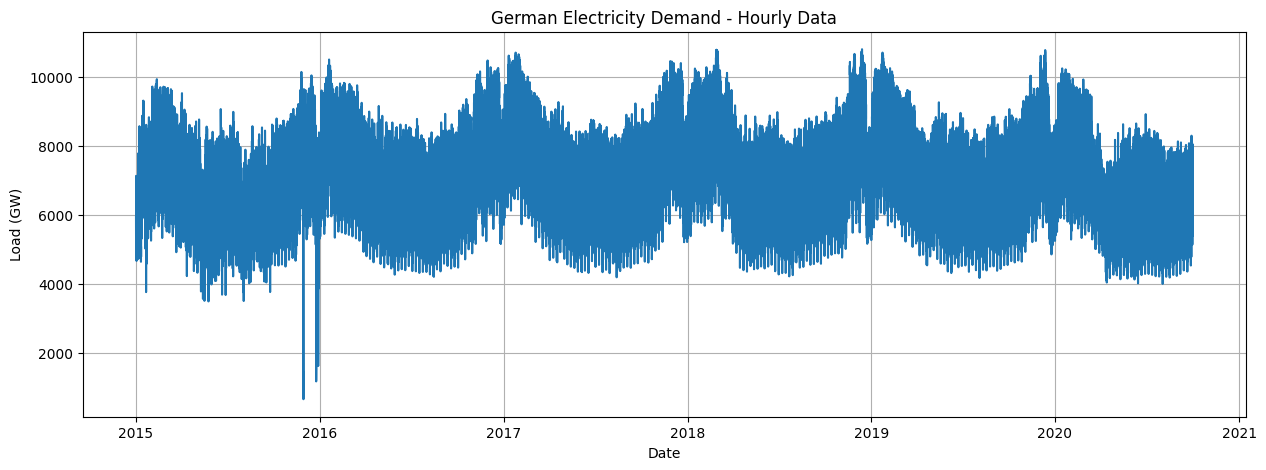

In [18]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df["load"])
plt.title("German Electricity Demand - Hourly Data")
plt.xlabel("Date")
plt.ylabel("Load (GW)")
plt.grid()
plt.show()

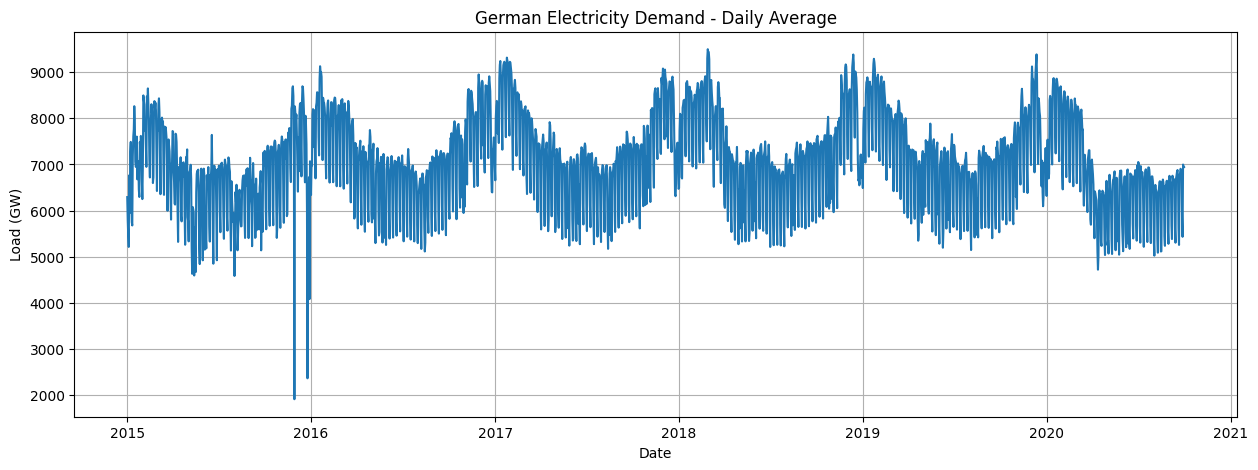

In [19]:
plt.figure(figsize=(15,5))
plt.plot(daily.index, daily["load"])
plt.title("German Electricity Demand - Daily Average")
plt.xlabel("Date")
plt.ylabel("Load (GW)")
plt.grid()
plt.show()

### Demand Distribution Analysis

The distribution and boxplot were used to examine the spread of electricity demand values and identify possible extreme observations.

The variation in demand reflects seasonal changes rather than random fluctuations alone.

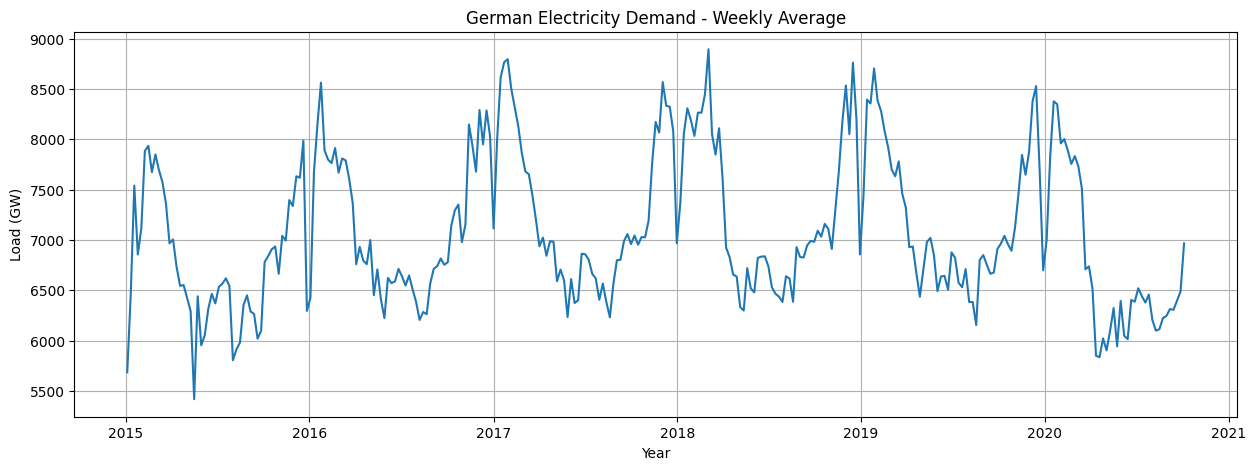

In [20]:
plt.figure(figsize=(15,5))
plt.plot(
    weekly.index,
    weekly["load"]
)
plt.title(
    "German Electricity Demand - Weekly Average"
)
plt.xlabel("Year")
plt.ylabel("Load (GW)")
plt.grid()
plt.show()

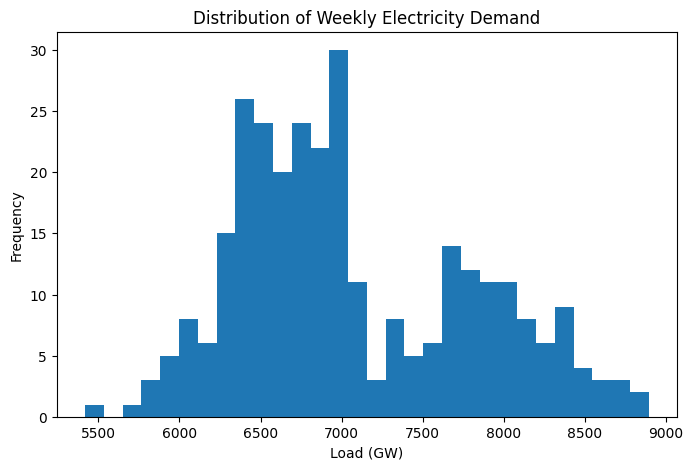

In [21]:
plt.figure(figsize=(8,5))
plt.hist(
    weekly["load"],
    bins=30
)
plt.title(
    "Distribution of Weekly Electricity Demand"
)
plt.xlabel("Load (GW)")
plt.ylabel("Frequency")
plt.show()

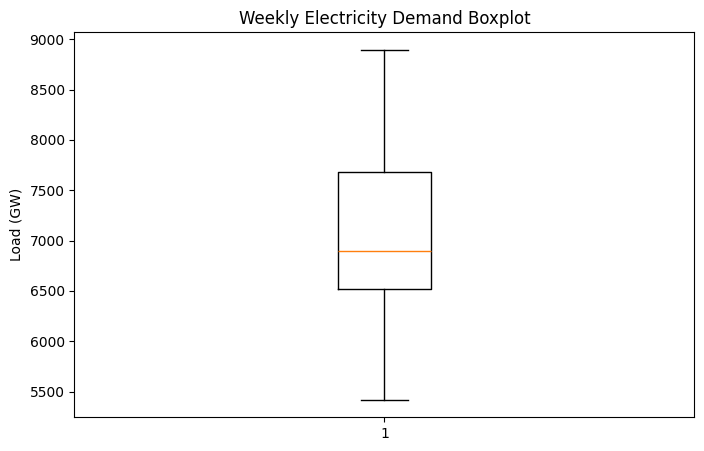

In [22]:
plt.figure(figsize=(8,5))
plt.boxplot(
    weekly["load"]
)
plt.title(
    "Weekly Electricity Demand Boxplot"
)
plt.ylabel("Load (GW)")
plt.show()

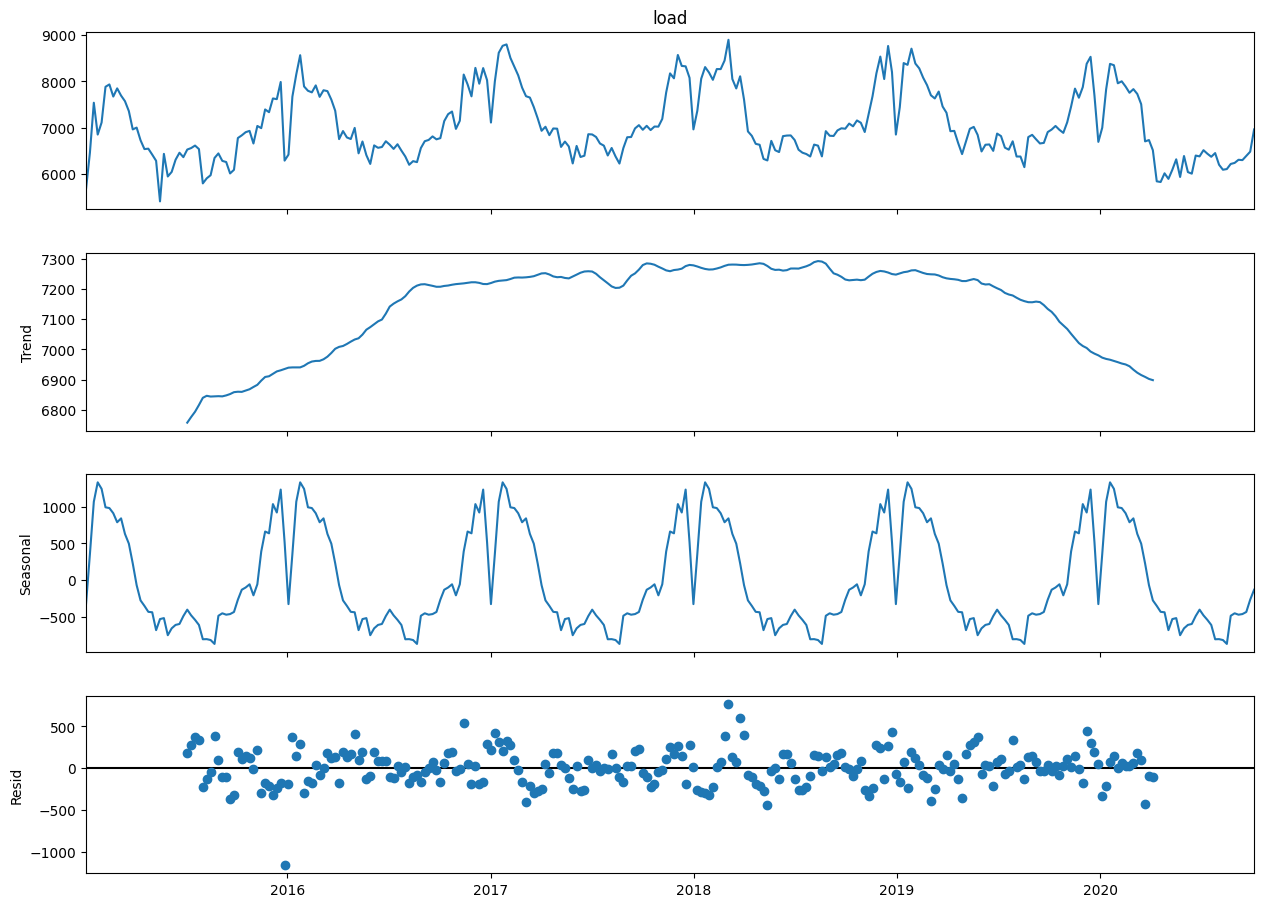

In [23]:
decomposition = seasonal_decompose(
    weekly["load"],
    model="additive",
    period=52
)
decomposition.plot()
plt.gcf().set_size_inches(14, 10)
plt.show()

# 4. Stationarity Analysis

Time series forecasting models such as SARIMA require the underlying series to be approximately stationary.

The Augmented Dickey-Fuller (ADF) test was applied to investigate whether the demand series contains a unit root.

Differencing was performed when required to remove non-stationary behaviour.

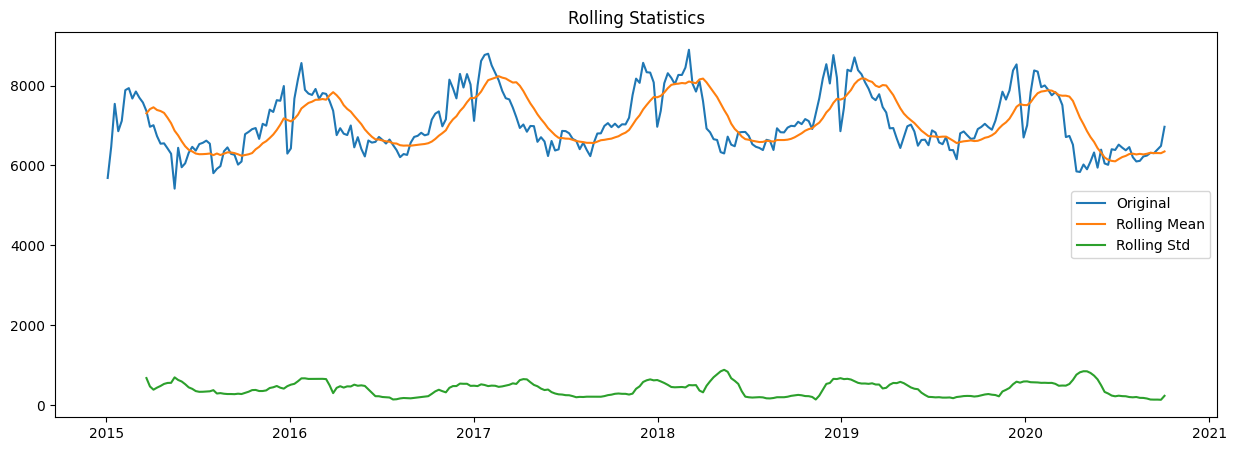

In [24]:
rolling_mean = weekly["load"].rolling(
    window=12
).mean()
rolling_std = weekly["load"].rolling(
    window=12
).std()
plt.figure(figsize=(15,5))
plt.plot(
    weekly["load"],
    label="Original"
)
plt.plot(
    rolling_mean,
    label="Rolling Mean"
)
plt.plot(
    rolling_std,
    label="Rolling Std"
)
plt.legend()
plt.title(
    "Rolling Statistics"
)
plt.show()

In [25]:
adf_result = adfuller(
    weekly["load"]
)
print(
    "ADF statistic:",
    adf_result[0]
)
print(
    "ADF p-value:",
    adf_result[1]
)

ADF statistic: -5.465774354944167
ADF p-value: 2.4608318146703345e-06


In [26]:
kpss_result = kpss(
    weekly["load"],
    regression="c"
)
print(
    "KPSS statistic:",
    kpss_result[0]
)
print(
    "KPSS p-value:",
    kpss_result[1]
)

KPSS statistic: 0.11282079852702855
KPSS p-value: 0.1


/tmp/ipykernel_646/2169177135.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(


In [27]:
weekly_diff = weekly["load"].diff()
weekly_diff = weekly_diff.dropna()

### First Differencing

The first difference transformation removes changes in the mean level of the series.

After differencing, the series shows reduced trend behaviour and improved stationarity.

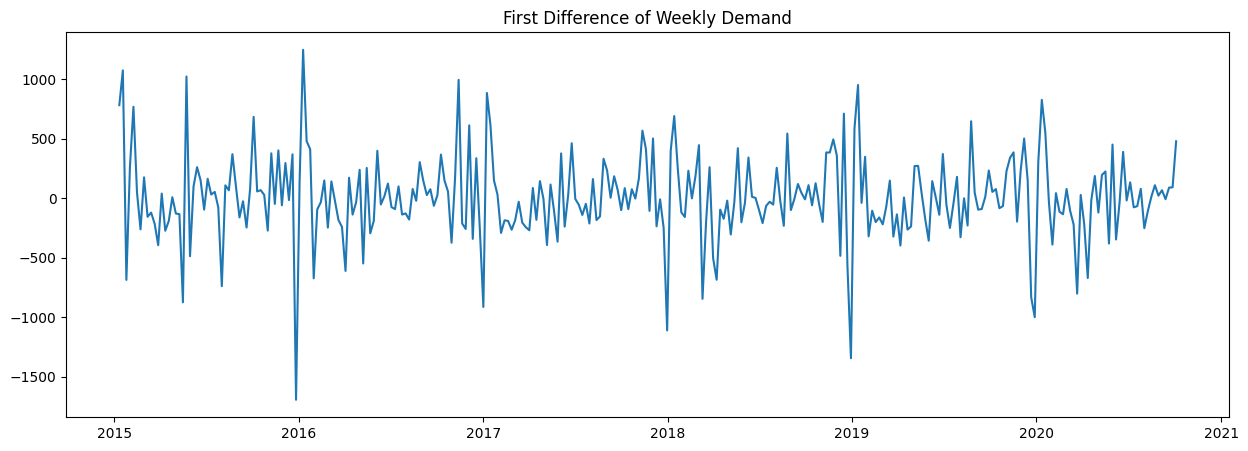

In [28]:
plt.figure(figsize=(15,5))
plt.plot(
    weekly_diff
)
plt.title(
    "First Difference of Weekly Demand"
)
plt.show()

### Autocorrelation Analysis

ACF and PACF plots were examined to understand temporal dependencies and support selection of autoregressive and moving average parameters.

In [29]:
adfuller(
    weekly_diff
)

(np.float64(-10.694072400830256),
 np.float64(3.6628024819789218e-19),
 3,
 296,
 {'1%': np.float64(-3.452636878592149),
  '5%': np.float64(-2.8713543954331433),
  '10%': np.float64(-2.5719993576515705)},
 np.float64(4114.688168043196))

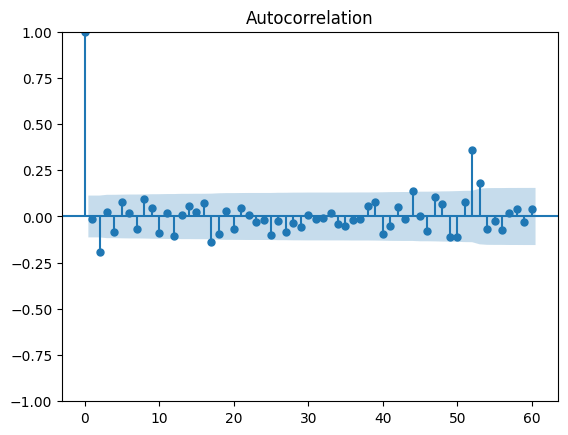

In [30]:
plot_acf(
    weekly_diff,
    lags=60
)
plt.show()

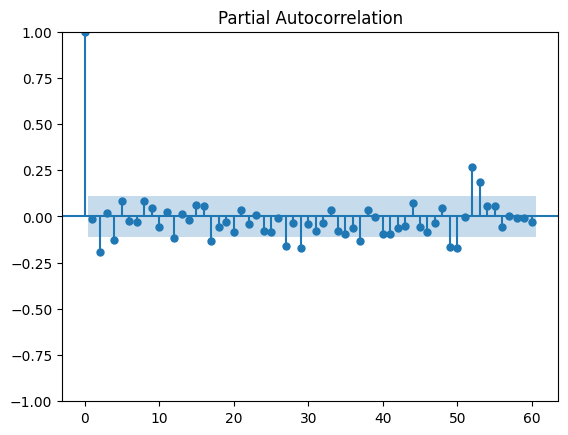

In [31]:
plot_pacf(
    weekly_diff,
    lags=60
)
plt.show()

# 5. Benchmark Forecasting Models

Simple forecasting methods were implemented as baseline comparisons.

These models provide reference performance levels that more complex forecasting models must improve upon.

The benchmark methods include:
- Mean forecast
- Naive forecast
- Seasonal naive forecast
- Drift forecast

A two-year forecasting horizon was used according to the assignment requirements.

In [32]:
TEST_WEEKS = 104
train = weekly.iloc[:-TEST_WEEKS]
test = weekly.iloc[-TEST_WEEKS:]
print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 197
Testing observations: 104


In [33]:
def mean_forecast(train, horizon):
    return pd.Series(
        np.mean(train["load"]),
        index=test.index
    )

In [34]:
def naive_forecast(train, horizon):
    last_value = train["load"].iloc[-1]
    return pd.Series(
        last_value,
        index=test.index
    )

In [35]:
def seasonal_naive_forecast(train, horizon):
    seasonal_values = train["load"].iloc[-52:]
    forecast = []
    for i in range(horizon):
        forecast.append(
            seasonal_values.iloc[i % 52]
        )
    return pd.Series(
        forecast,
        index=test.index
    )

In [36]:
def drift_forecast(train, horizon):
    y = train["load"]
    drift = (
        y.iloc[-1] - y.iloc[0]
    ) / (len(y)-1)
    forecast = [
        y.iloc[-1] + drift*(i+1)
        for i in range(horizon)
    ]
    return pd.Series(
        forecast,
        index=test.index
    )

In [37]:
forecasts = {}
forecasts["Mean"] = mean_forecast(
    train,
    TEST_WEEKS
)
forecasts["Naive"] = naive_forecast(
    train,
    TEST_WEEKS
)
forecasts["Seasonal Naive"] = seasonal_naive_forecast(
    train,
    TEST_WEEKS
)
forecasts["Drift"] = drift_forecast(
    train,
    TEST_WEEKS
)

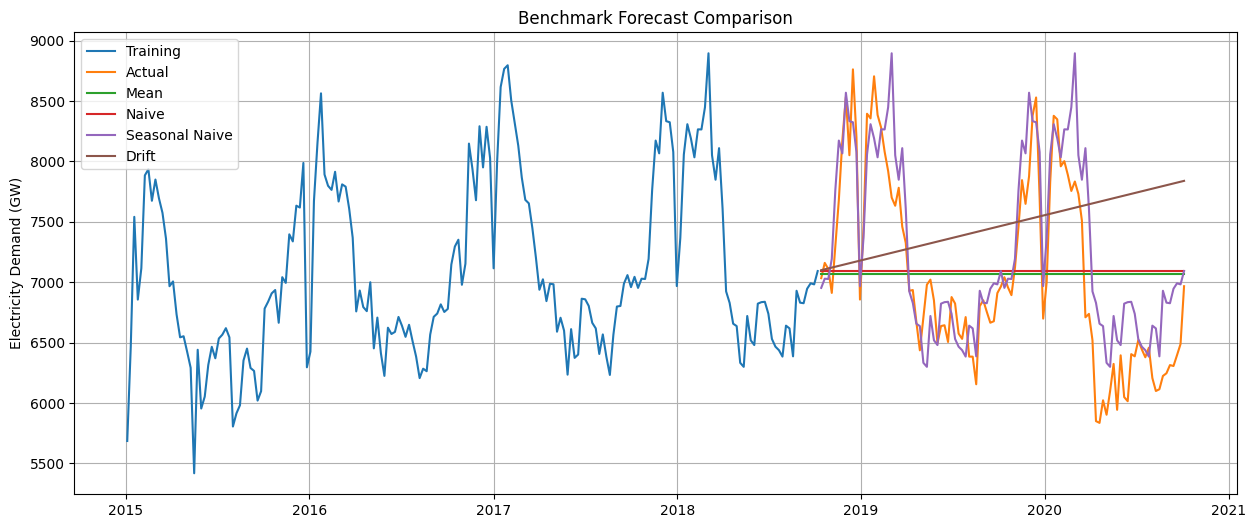

In [38]:
plt.figure(figsize=(15,6))
plt.plot(
    train.index,
    train["load"],
    label="Training"
)
plt.plot(
    test.index,
    test["load"],
    label="Actual"
)
for name, prediction in forecasts.items():

    plt.plot(
        prediction.index,
        prediction,
        label=name
    )
plt.title(
    "Benchmark Forecast Comparison"
)
plt.ylabel(
    "Electricity Demand (GW)"
)
plt.legend()
plt.grid()
plt.show()

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [40]:
def rmse(actual, predicted):
    return np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

In [41]:
def mase(actual, predicted, training):
    naive_error = np.mean(
        np.abs(
            training.diff().dropna()
        )
    )
    forecast_error = np.mean(
        np.abs(
            actual - predicted
        )
    )
    return forecast_error / naive_error

In [42]:
results = []
for name, prediction in forecasts.items():
    results.append({
        "Model": name,
        "RMSE":
        rmse(
            test["load"],
            prediction
        ),
        "MAE":
        mean_absolute_error(
            test["load"],
            prediction
        ),
        "MASE":
        mase(
            test["load"],
            prediction,
            train["load"]
        )
    })
results_df = pd.DataFrame(results)
results_df

,Model,RMSE,MAE,MASE
0,Mean,762.119830,646.913283,2.591379
1,Naive,762.574416,652.159760,2.612396
2,Seasonal Naive,424.459965,325.753053,1.304889
3,Drift,978.935316,833.887468,3.340353


In [43]:
results_df.to_csv(
    "benchmark_results.csv",
    index=False
)

# 6. SARIMA Forecasting Model

The exploratory analysis identified strong yearly seasonality in electricity demand.

Therefore, a Seasonal Autoregressive Integrated Moving Average (SARIMA) model was developed.

The seasonal period was selected as 52 weeks because the data were aggregated weekly and electricity demand shows annual seasonal patterns.

In [44]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
import warnings
warnings.filterwarnings("ignore")

In [45]:
y_train = train["load"]
y_test = test["load"]
print(len(y_train))
print(len(y_test))

197
104


### SARIMA Parameter Selection

The best SARIMA parameters were selected using an AIC-based grid search.

The required parameter ranges were:

p = [0,6]

d = [0,2]

q = [0,6]

This resulted in 147 possible combinations:

7 × 3 × 7 = 147 models.

The seasonal parameters were fixed because the yearly seasonal period was already identified from exploratory analysis.

In [46]:
from itertools import product
import pandas as pd
import numpy as np
import warnings
import time
from statsmodels.tsa.statespace.sarimax import SARIMAX
p_values = range(0, 7)
d_values = range(0, 3)
q_values = range(0, 7)
results = []
best_aic = np.inf
best_order = None
total_models = len(p_values) * len(d_values) * len(q_values)
completed = 0
start = time.time()
print(f"Searching {total_models} SARIMA models...\n")
# Grid Search
for p, d, q in product(p_values, d_values, q_values):
    completed += 1
    try:
        model = SARIMAX(
            y_train,
            order=(p, d, q),
            seasonal_order=(1, 1, 1, 52),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fitted = model.fit(
            method="powell",      # Faster for grid search
            maxiter=15,
            disp=False
        )
        aic = fitted.aic
        results.append({
            "p": p,
            "d": d,
            "q": q,
            "AIC": aic
        })
        if aic < best_aic:
            best_aic = aic
            best_order = (p, d, q)
            print(
                f"Best so far: SARIMA{best_order} "
                f"| AIC={best_aic:.2f}"
            )
    except Exception:
        pass
    if completed % 10 == 0 or completed == total_models:
        elapsed = time.time() - start
        print(
            f"Completed {completed}/{total_models} "
            f"({elapsed/60:.1f} min)"
        )
# Results
sarima_results = (
    pd.DataFrame(results)
    .sort_values("AIC")
    .reset_index(drop=True)
)
print("\n==========================")
print("Best Model")
print("==========================")
print(sarima_results.head())
print("\nBest Order:", best_order)
print("Best AIC:", best_aic)
print(
    "\nTotal Time:",
    round((time.time()-start)/60,2),
    "minutes"
)
sarima_results.to_csv(
    "sarima_grid_search_results.csv",
    index=False
)

Searching 147 SARIMA models...

Best so far: SARIMA(0, 0, 0) | AIC=1333.58
Best so far: SARIMA(0, 0, 1) | AIC=1265.96
Best so far: SARIMA(0, 0, 2) | AIC=1252.96
Best so far: SARIMA(0, 0, 3) | AIC=1231.50
Best so far: SARIMA(0, 0, 4) | AIC=1209.46
Best so far: SARIMA(0, 0, 5) | AIC=1198.33
Best so far: SARIMA(0, 0, 6) | AIC=1187.67
Completed 10/147 (2.9 min)
Best so far: SARIMA(0, 1, 6) | AIC=1174.12
Completed 20/147 (7.6 min)
Best so far: SARIMA(0, 2, 6) | AIC=1169.18
Completed 30/147 (13.4 min)
Completed 40/147 (17.6 min)
Completed 50/147 (23.9 min)
Completed 60/147 (28.5 min)
Completed 70/147 (35.5 min)
Completed 80/147 (41.4 min)
Completed 90/147 (48.7 min)
Completed 100/147 (59.0 min)
Completed 110/147 (66.6 min)
Completed 120/147 (78.2 min)
Completed 130/147 (88.5 min)
Completed 140/147 (102.9 min)
Completed 147/147 (109.7 min)

Best Model
   p  d  q          AIC
0  0  2  6  1169.182675
1  4  1  6  1172.150545
2  6  1  6  1173.649532
3  0  1  6  1174.120845
4  5  1  6  1174.440316

In [47]:
sarima_results = pd.DataFrame(
    results,
    columns=[
        "p",
        "d",
        "q",
        "AIC"
    ]
)
sarima_results.sort_values(
    "AIC"
).head()

,p,d,q,AIC
20,0,2,6,1169.182675
97,4,1,6,1172.150545
139,6,1,6,1173.649532
13,0,1,6,1174.120845
118,5,1,6,1174.440316


In [48]:
best = sarima_results.sort_values(
    "AIC"
).iloc[0]
print(best)

p         0.000000
d         2.000000
q         6.000000
AIC    1169.182675
Name: 20, dtype: float64


In [49]:
best_model = SARIMAX(
    y_train,
    order=(
        int(best["p"]),
        int(best["d"]),
        int(best["q"])
    ),
    seasonal_order=(1,1,1,52),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = best_model.fit()
print(
    sarima_fit.summary()
)

                                      SARIMAX Results                                       
Dep. Variable:                                 load   No. Observations:                  197
Model:             SARIMAX(0, 2, 6)x(1, 1, [1], 52)   Log Likelihood                -584.897
Date:                              Wed, 15 Jul 2026   AIC                           1187.794
Time:                                      14:53:06   BIC                           1209.671
Sample:                                  01-04-2015   HQIC                          1196.589
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.2198      0.218     -5.606      0.000      -1.646      -0.793
ma.L2         -0.15

In [50]:
residuals = sarima_fit.residuals

### Residual Diagnostics

Residual analysis was performed to evaluate whether important patterns remained after model fitting.

Ideally, residuals should behave like random noise with limited autocorrelation.

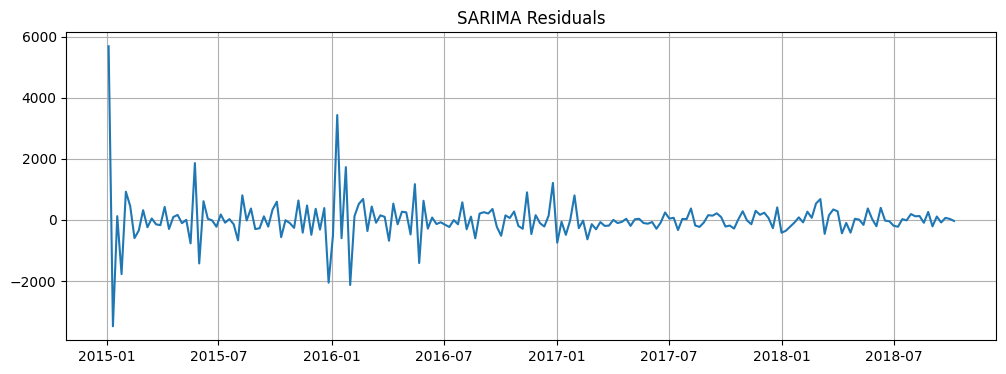

In [51]:
plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title(
    "SARIMA Residuals"
)
plt.grid()
plt.show()

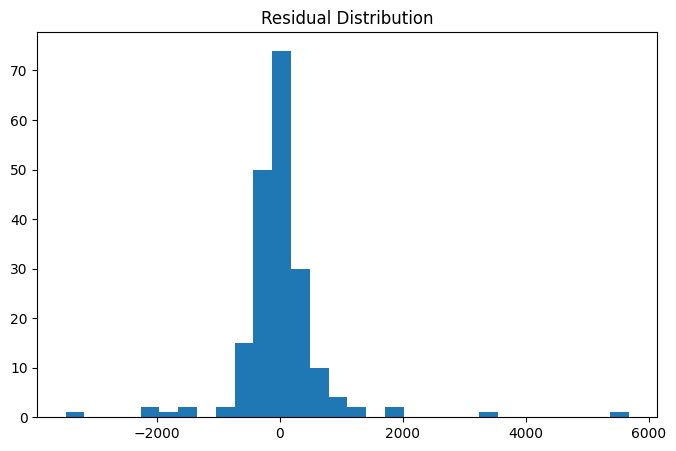

In [52]:
plt.figure(figsize=(8,5))
plt.hist(
    residuals,
    bins=30
)
plt.title(
    "Residual Distribution"
)
plt.show()

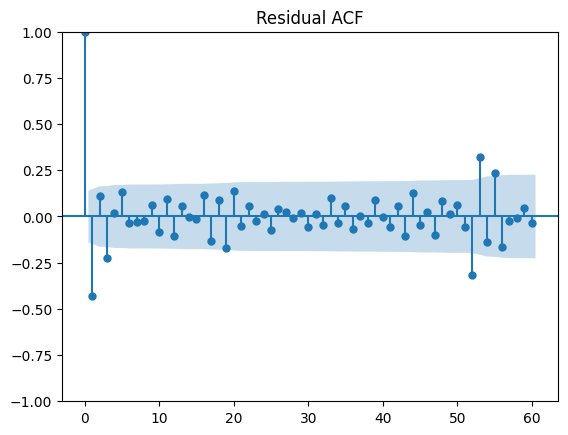

In [53]:
plot_acf(
    residuals.dropna(),
    lags=60
)
plt.title(
    "Residual ACF"
)
plt.show()

In [54]:
forecast_result = sarima_fit.get_forecast(
    steps=len(y_test)
)
sarima_prediction = forecast_result.predicted_mean
confidence = forecast_result.conf_int()

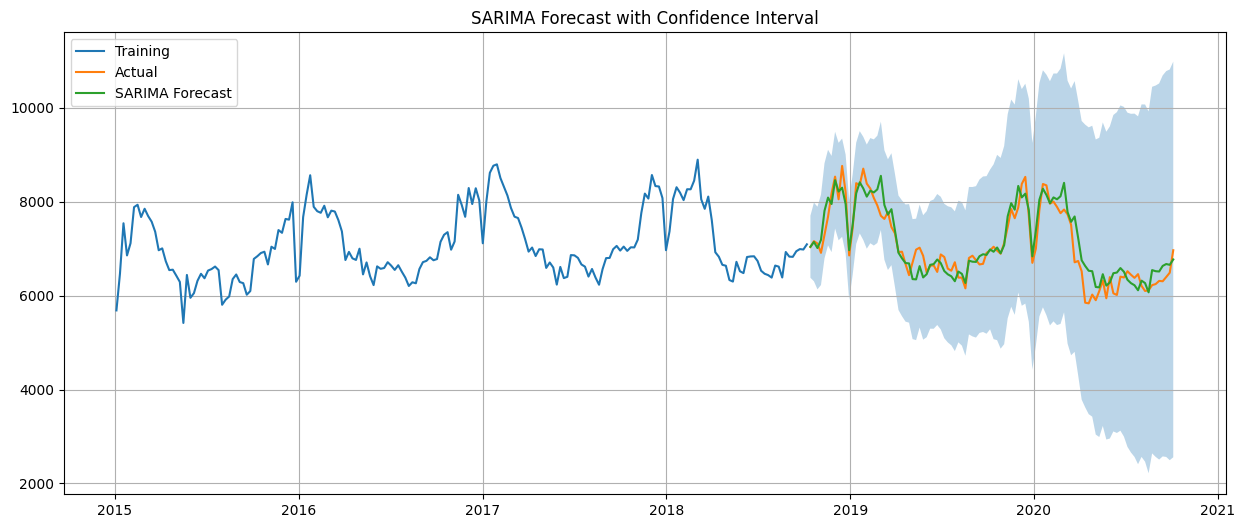

In [55]:
plt.figure(figsize=(15,6))
plt.plot(
    y_train.index,
    y_train,
    label="Training"
)
plt.plot(
    y_test.index,
    y_test,
    label="Actual"
)
plt.plot(
    sarima_prediction.index,
    sarima_prediction,
    label="SARIMA Forecast"
)
plt.fill_between(
    confidence.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    alpha=0.3
)
plt.legend()

plt.title(
    "SARIMA Forecast with Confidence Interval"
)
plt.grid()
plt.show()

In [56]:
sarima_rmse = rmse(
    y_test,
    sarima_prediction
)
sarima_mae = mean_absolute_error(
    y_test,
    sarima_prediction
)
print(
    "SARIMA RMSE:",
    sarima_rmse
)
print(
    "SARIMA MAE:",
    sarima_mae
)

SARIMA RMSE: 295.13702149252896
SARIMA MAE: 226.62931975749396


# 7. SARIMAX Model with Temperature Variables

Electricity demand is strongly influenced by weather conditions, especially heating requirements during cold periods.

Temperature variables were introduced as external explanatory variables to create a SARIMAX model.

The additional variables include:
- Mean temperature
- Minimum temperature
- Maximum temperature
- Heating degree days
- Cooling degree days

In [57]:
import pandas as pd
import requests
latitude = 52.52
longitude = 13.41
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": "2015-01-01",
    "end_date": "2020-10-31",
    "daily": [
        "temperature_2m_mean",
        "temperature_2m_min",
        "temperature_2m_max"
    ],
    "timezone": "Europe/Berlin"
}
response = requests.get(
    url,
    params=params
)
temperature_json = response.json()

In [58]:
temperature = pd.DataFrame(
    temperature_json["daily"]
)
temperature["time"] = pd.to_datetime(
    temperature["time"]
)

# Localize to Europe/Berlin first, then convert to UTC to match the 'weekly' DataFrame's index
temperature["time"] = temperature["time"].dt.tz_localize("Europe/Berlin", ambiguous='NaT', nonexistent='NaT').dt.tz_convert("UTC")
temperature = temperature.set_index(
    "time"
)
temperature.head()

,temperature_2m_mean,temperature_2m_min,temperature_2m_max
time,,,
2014-12-31 23:00:00+00:00,2.8,0.9,4.4
2015-01-01 23:00:00+00:00,4.6,1.6,7.5
2015-01-02 23:00:00+00:00,3.9,2.9,5.1
2015-01-03 23:00:00+00:00,3.0,1.6,4.2
2015-01-04 23:00:00+00:00,2.7,1.1,3.7


In [59]:
temperature = temperature.rename(
    columns={
        "temperature_2m_mean":"temp_mean",
        "temperature_2m_min":"temp_min",
        "temperature_2m_max":"temp_max"
    }
)

In [60]:
weekly_temperature = temperature.resample("W").mean()
weekly_temperature.index = weekly_temperature.index - pd.Timedelta(hours=23)

In [61]:
weekly_features = weekly.join(
    weekly_temperature,
    how="inner"
)

In [62]:
weekly_features.head()

,load,temp_mean,temp_min,temp_max


In [63]:
weekly_features["heating_degree_days"] = (
    18 - weekly_features["temp_mean"]
).clip(lower=0)
weekly_features["cooling_degree_days"] = (
    weekly_features["temp_mean"] - 22
).clip(lower=0)

In [65]:
weekly_features.info()
weekly_features.isna().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 0 entries
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   load                 0 non-null      float64
 1   temp_mean            0 non-null      float64
 2   temp_min             0 non-null      float64
 3   temp_max             0 non-null      float64
 4   heating_degree_days  0 non-null      float64
 5   cooling_degree_days  0 non-null      float64
dtypes: float64(6)
memory usage: 0.0 bytes


,0
load,0
temp_mean,0
temp_min,0
temp_max,0
heating_degree_days,0
cooling_degree_days,0


In [66]:
weekly_features.columns

Index(['load', 'temp_mean', 'temp_min', 'temp_max', 'heating_degree_days',
       'cooling_degree_days'],
      dtype='object')

In [67]:
print(weekly.index[:5])
print(weekly_temperature.index[:5])

DatetimeIndex(['2015-01-04 00:00:00+00:00', '2015-01-11 00:00:00+00:00',
               '2015-01-18 00:00:00+00:00', '2015-01-25 00:00:00+00:00',
               '2015-02-01 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='utc_timestamp', freq='W-SUN')
DatetimeIndex(['2015-01-03 01:00:00+00:00', '2015-01-10 01:00:00+00:00',
               '2015-01-17 01:00:00+00:00', '2015-01-24 01:00:00+00:00',
               '2015-01-31 01:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='time', freq=None)


In [68]:
weekly_features = weekly.join(
    weekly_temperature,
    how="inner"
)

In [69]:
weekly_features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 0 entries
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   load       0 non-null      float64
 1   temp_mean  0 non-null      float64
 2   temp_min   0 non-null      float64
 3   temp_max   0 non-null      float64
dtypes: float64(4)
memory usage: 0.0 bytes


In [70]:
weekly_features["heating_degree_days"] = (
    18 - weekly_features["temp_mean"]
).clip(lower=0)
weekly_features["cooling_degree_days"] = (
    weekly_features["temp_mean"] - 22
).clip(lower=0)

In [71]:
print(weekly_features.head())
print(weekly_features.shape)
print(weekly_features.isna().sum())

Empty DataFrame
Columns: [load, temp_mean, temp_min, temp_max, heating_degree_days, cooling_degree_days]
Index: []
(0, 6)
load                   0
temp_mean              0
temp_min               0
temp_max               0
heating_degree_days    0
cooling_degree_days    0
dtype: int64


In [72]:
print("Electricity weekly dates:")
print(weekly.index[:10])
print("\nTemperature weekly dates:")
print(weekly_temperature.index[:10])
print("\nIndex types:")
print(type(weekly.index))
print(type(weekly_temperature.index))

Electricity weekly dates:
DatetimeIndex(['2015-01-04 00:00:00+00:00', '2015-01-11 00:00:00+00:00',
               '2015-01-18 00:00:00+00:00', '2015-01-25 00:00:00+00:00',
               '2015-02-01 00:00:00+00:00', '2015-02-08 00:00:00+00:00',
               '2015-02-15 00:00:00+00:00', '2015-02-22 00:00:00+00:00',
               '2015-03-01 00:00:00+00:00', '2015-03-08 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='utc_timestamp', freq='W-SUN')

Temperature weekly dates:
DatetimeIndex(['2015-01-03 01:00:00+00:00', '2015-01-10 01:00:00+00:00',
               '2015-01-17 01:00:00+00:00', '2015-01-24 01:00:00+00:00',
               '2015-01-31 01:00:00+00:00', '2015-02-07 01:00:00+00:00',
               '2015-02-14 01:00:00+00:00', '2015-02-21 01:00:00+00:00',
               '2015-02-28 01:00:00+00:00', '2015-03-07 01:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='time', freq=None)

Index types:
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
<

In [73]:
weekly_temperature = temperature.resample(
    "W-SUN"
).mean()

In [74]:
weekly.index = weekly.index.to_period("W-SUN").to_timestamp()
weekly_temperature.index = weekly_temperature.index.to_period("W-SUN").to_timestamp()

In [75]:
print(
    len(
        weekly.index.intersection(
            weekly_temperature.index
        )
    )
)

301


In [76]:
weekly_features = weekly.join(
    weekly_temperature,
    how="inner"
)

In [77]:
print(weekly_features.shape)

print(weekly_features.head())

(301, 4)
                   load  temp_mean  temp_min  temp_max
2014-12-29  5685.072917   3.400000  1.620000  4.980000
2015-01-05  6467.083333   4.171429  2.028571  6.528571
2015-01-12  7540.803571   4.142857  1.128571  7.042857
2015-01-19  6855.744048   0.357143 -1.000000  2.085714
2015-01-26  7115.559524   1.242857 -0.457143  2.971429


In [78]:
print(weekly.index.min())
print(weekly.index.max())
print(weekly_temperature.index.min())
print(weekly_temperature.index.max())

2014-12-29 00:00:00
2020-09-28 00:00:00
2014-12-29 00:00:00
2020-10-26 00:00:00


In [79]:
common_dates = weekly.index.intersection(
    weekly_temperature.index
)
print(len(common_dates))
print(common_dates[:10])

301
DatetimeIndex(['2014-12-29', '2015-01-05', '2015-01-12', '2015-01-19',
               '2015-01-26', '2015-02-02', '2015-02-09', '2015-02-16',
               '2015-02-23', '2015-03-02'],
              dtype='datetime64[ns]', freq='W-MON')


In [80]:
weekly_features = pd.concat(
    [
        weekly,
        weekly_temperature
    ],
    axis=1
)

weekly_features = weekly_features.dropna()

In [81]:
print(weekly_features.shape)
print(weekly_features.head())

(301, 4)
                   load  temp_mean  temp_min  temp_max
2014-12-29  5685.072917   3.400000  1.620000  4.980000
2015-01-05  6467.083333   4.171429  2.028571  6.528571
2015-01-12  7540.803571   4.142857  1.128571  7.042857
2015-01-19  6855.744048   0.357143 -1.000000  2.085714
2015-01-26  7115.559524   1.242857 -0.457143  2.971429


In [82]:
weekly_features["heating_degree_days"] = (
    18 - weekly_features["temp_mean"]
).clip(lower=0)


weekly_features["cooling_degree_days"] = (
    weekly_features["temp_mean"] - 22
).clip(lower=0)

In [83]:
print(
len(
weekly.index.intersection(weekly_temperature.index)
)
)

301


In [84]:
weekly_features = pd.concat(
    [
        weekly,
        weekly_temperature
    ],
    axis=1
)
weekly_features = weekly_features.dropna()

In [85]:
print(weekly_features.shape)

print(weekly_features.head())

(301, 4)
                   load  temp_mean  temp_min  temp_max
2014-12-29  5685.072917   3.400000  1.620000  4.980000
2015-01-05  6467.083333   4.171429  2.028571  6.528571
2015-01-12  7540.803571   4.142857  1.128571  7.042857
2015-01-19  6855.744048   0.357143 -1.000000  2.085714
2015-01-26  7115.559524   1.242857 -0.457143  2.971429


In [86]:
weekly_features["heating_degree_days"] = (
    18 - weekly_features["temp_mean"]
).clip(lower=0)


weekly_features["cooling_degree_days"] = (
    weekly_features["temp_mean"] - 22
).clip(lower=0)

In [87]:
weekly_features = weekly_features.rename(
    columns={
        "load": "load_gw"
    }
)

In [88]:
weekly_features.to_csv(
    "weekly_features.csv"
)

In [89]:
print(weekly_features.info())

print(weekly_features.head())

print(weekly_features.isna().sum())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 301 entries, 2014-12-29 to 2020-09-28
Freq: W-MON
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   load_gw              301 non-null    float64
 1   temp_mean            301 non-null    float64
 2   temp_min             301 non-null    float64
 3   temp_max             301 non-null    float64
 4   heating_degree_days  301 non-null    float64
 5   cooling_degree_days  301 non-null    float64
dtypes: float64(6)
memory usage: 16.5 KB
None
                load_gw  temp_mean  temp_min  temp_max  heating_degree_days  \
2014-12-29  5685.072917   3.400000  1.620000  4.980000            14.600000   
2015-01-05  6467.083333   4.171429  2.028571  6.528571            13.828571   
2015-01-12  7540.803571   4.142857  1.128571  7.042857            13.857143   
2015-01-19  6855.744048   0.357143 -1.000000  2.085714            17.642857   
2015-01-26  7115.559524 

In [90]:
TEST_WEEKS = 104

train_smx = weekly_features.iloc[:-TEST_WEEKS]

test_smx = weekly_features.iloc[-TEST_WEEKS:]

print(train_smx.shape)
print(test_smx.shape)

(197, 6)
(104, 6)


In [91]:
y_train = train_smx["load_gw"]

y_test = test_smx["load_gw"]

In [92]:
exog_columns = [
    "temp_mean",
    "heating_degree_days",
    "cooling_degree_days"
]


X_train = train_smx[exog_columns]

X_test = test_smx[exog_columns]

In [93]:
print(X_train.head())

print(X_train.shape)

            temp_mean  heating_degree_days  cooling_degree_days
2014-12-29   3.400000            14.600000                  0.0
2015-01-05   4.171429            13.828571                  0.0
2015-01-12   4.142857            13.857143                  0.0
2015-01-19   0.357143            17.642857                  0.0
2015-01-26   1.242857            16.757143                  0.0
(197, 3)


In [94]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [95]:
sarimax_model = SARIMAX(
    y_train,
    exog=X_train,
    order=(p,d,q),
    seasonal_order=(1,1,1,52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

In [97]:
sarimax_fit = sarimax_model.fit()

print(sarimax_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                              load_gw   No. Observations:                  197
Model:             SARIMAX(6, 2, 6)x(1, 1, [1], 52)   Log Likelihood                -566.444
Date:                              Wed, 15 Jul 2026   AIC                           1168.888
Time:                                      14:55:49   BIC                           1212.643
Sample:                                  12-29-2014   HQIC                          1186.477
                                       - 10-01-2018                                         
Covariance Type:                                opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
temp_mean              20.4857     50.174      0.408      0.683     -77.854     

In [98]:
sarimax_forecast = sarimax_fit.get_forecast(
    steps=len(test_smx),
    exog=X_test
)

In [99]:
sarimax_prediction = sarimax_forecast.predicted_mean

In [100]:
sarimax_conf = sarimax_forecast.conf_int()

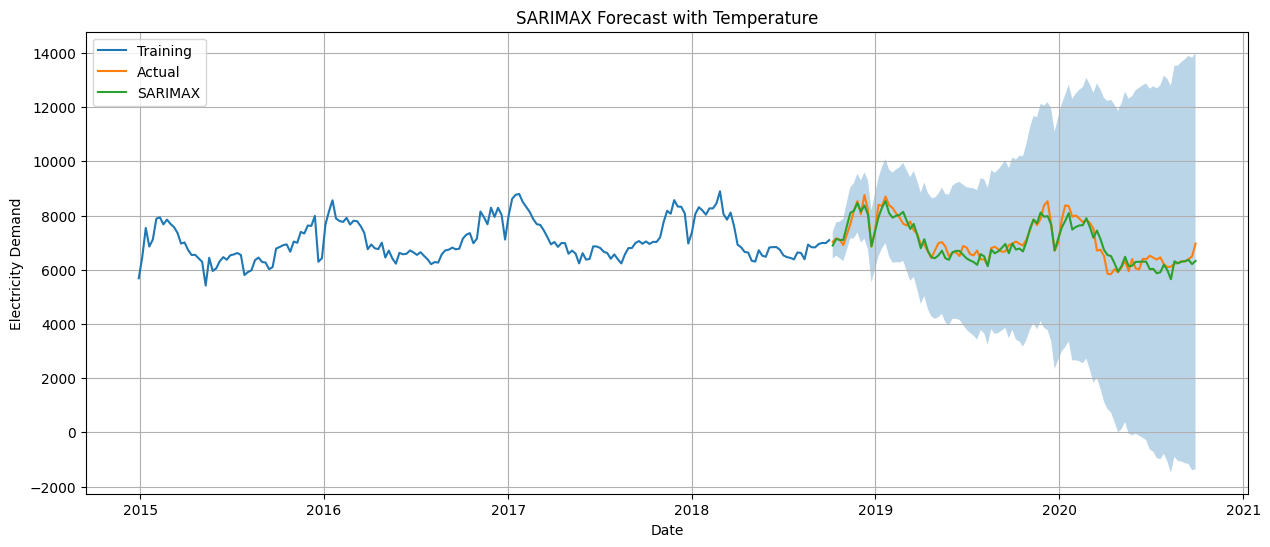

In [101]:
plt.figure(figsize=(15,6))

plt.plot(
    y_train.index,
    y_train,
    label="Training"
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual"
)

plt.plot(
    sarimax_prediction.index,
    sarimax_prediction,
    label="SARIMAX"
)

plt.fill_between(
    sarimax_conf.index,
    sarimax_conf.iloc[:,0],
    sarimax_conf.iloc[:,1],
    alpha=0.3
)

plt.title(
    "SARIMAX Forecast with Temperature"
)

plt.xlabel("Date")
plt.ylabel("Electricity Demand")

plt.legend()
plt.grid()

plt.show()

In [102]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [103]:
sarimax_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        sarimax_prediction
    )
)

In [104]:
sarimax_mae = mean_absolute_error(
    y_test,
    sarimax_prediction
)

In [105]:
print("SARIMAX RMSE:", sarimax_rmse)
print("SARIMAX MAE:", sarimax_mae)

SARIMAX RMSE: 286.45306409590006
SARIMAX MAE: 222.4040570984838


In [106]:
comparison = pd.DataFrame(
    {
        "Model":[
            "SARIMA",
            "SARIMAX"
        ],
        "RMSE":[
            sarima_rmse,
            sarimax_rmse
        ],
        "MAE":[
            sarima_mae,
            sarimax_mae
        ]
    }
)

comparison

,Model,RMSE,MAE
0,SARIMA,295.137021,226.629320
1,SARIMAX,286.453064,222.404057


In [108]:
sarimax_results = pd.DataFrame(
    {
        "Model": ["SARIMAX"],
        "RMSE": [sarimax_rmse],
        "MAE": [sarimax_mae]
    }
)

sarimax_results.to_csv(
    "sarimax_results.csv",
    index=False
)

The SARIMAX model achieved improved performance compared with SARIMA.

This suggests that temperature information provides additional explanatory power for electricity demand forecasting.

However, because observed future temperature values were used, this represents a conditional forecast rather than a fully operational forecast.

# 8. Gradient Boosting Regression Model

A feature-based machine learning approach was implemented using Gradient Boosting Regression.

The model uses historical demand information and temperature-related features.

Lag variables were created only using previous observations to prevent future information leakage.

In [109]:
weekly_features.head()

,load_gw,temp_mean,temp_min,temp_max,heating_degree_days,cooling_degree_days
2014-12-29,5685.072917,3.400000,1.620000,4.980000,14.600000,0.0
2015-01-05,6467.083333,4.171429,2.028571,6.528571,13.828571,0.0
2015-01-12,7540.803571,4.142857,1.128571,7.042857,13.857143,0.0
2015-01-19,6855.744048,0.357143,-1.000000,2.085714,17.642857,0.0
2015-01-26,7115.559524,1.242857,-0.457143,2.971429,16.757143,0.0


In [110]:
weekly_features.columns

Index(['load_gw', 'temp_mean', 'temp_min', 'temp_max', 'heating_degree_days',
       'cooling_degree_days'],
      dtype='object')

In [111]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

In [112]:
ml_data = weekly_features.copy()

### Feature Engineering

The following features were created:

- Previous week demand
- Previous two weeks demand
- Previous four weeks demand
- Previous year demand (52 week lag)
- Rolling statistics
- Calendar features

These features allow the model to learn seasonal and temporal relationships.

In [113]:
ml_data["lag_1"] = ml_data["load_gw"].shift(1)
ml_data["lag_2"] = ml_data["load_gw"].shift(2)
ml_data["lag_4"] = ml_data["load_gw"].shift(4)
ml_data["lag_52"] = ml_data["load_gw"].shift(52)

In [114]:
ml_data["rolling_mean_4"] = (
    ml_data["load_gw"]
    .rolling(4)
    .mean()
)
ml_data["rolling_std_4"] = (
    ml_data["load_gw"]
    .rolling(4)
    .std()
)

In [115]:
ml_data["month"] = ml_data.index.month
ml_data["week"] = ml_data.index.isocalendar().week.astype(int)

In [116]:
ml_data = ml_data.dropna()

In [117]:
print(ml_data.shape)
ml_data.head()

(249, 14)


,load_gw,temp_mean,temp_min,temp_max,heating_degree_days,cooling_degree_days,lag_1,lag_2,lag_4,lag_52,rolling_mean_4,rolling_std_4,month,week
2015-12-28,6424.916667,-1.328571,-3.485714,0.800000,19.328571,0.0,6295.196429,7987.029762,7632.994048,5685.072917,7081.275298,847.967466,12,53
2016-01-04,7671.940476,-2.100000,-4.600000,0.114286,20.100000,0.0,6424.916667,6295.196429,7617.958333,6467.083333,7094.770833,859.704334,1,1
2016-01-11,8151.434524,-0.685714,-2.328571,1.100000,18.685714,0.0,7671.940476,6424.916667,7987.029762,7540.803571,7135.872024,918.500509,1,2
2016-01-18,8563.261905,-1.971429,-6.085714,1.385714,19.971429,0.0,8151.434524,7671.940476,6295.196429,6855.744048,7702.888393,926.571767,1,3
2016-01-25,7891.297619,6.285714,3.514286,8.757143,11.714286,0.0,8563.261905,8151.434524,6424.916667,7115.559524,8069.483631,383.111710,1,4


In [118]:
TEST_WEEKS = 104
train_ml = ml_data.iloc[:-TEST_WEEKS]
test_ml = ml_data.iloc[-TEST_WEEKS:]

In [119]:
y_train_ml = train_ml["load_gw"]
y_test_ml = test_ml["load_gw"]

In [120]:
X_train_ml = train_ml.drop(
    columns=["load_gw"]
)
X_test_ml = test_ml.drop(
    columns=["load_gw"]
)

In [121]:
print(X_train_ml.shape)
print(X_test_ml.shape)

(145, 13)
(104, 13)


In [122]:
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [123]:
gbr_model.fit(
    X_train_ml,
    y_train_ml
)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [124]:
gbr_prediction = gbr_model.predict(
    X_test_ml
)

In [125]:
gbr_prediction = pd.Series(
    gbr_prediction,
    index=test_ml.index
)

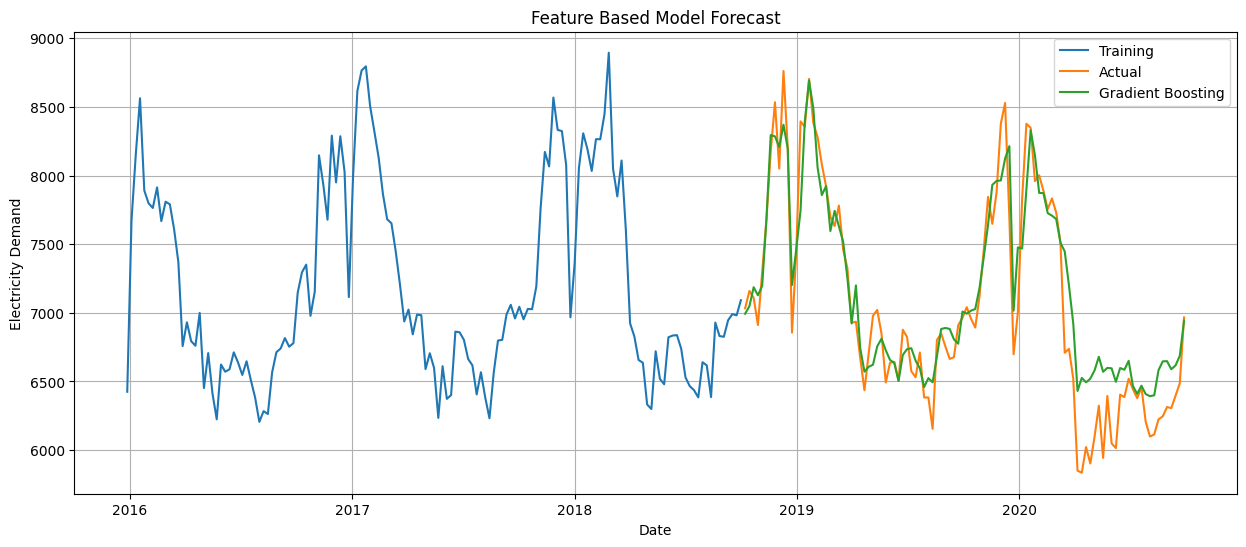

In [126]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,6))
plt.plot(
    y_train_ml.index,
    y_train_ml,
    label="Training"
)
plt.plot(
    y_test_ml.index,
    y_test_ml,
    label="Actual"
)
plt.plot(
    gbr_prediction.index,
    gbr_prediction,
    label="Gradient Boosting"
)
plt.title(
    "Feature Based Model Forecast"
)
plt.xlabel("Date")
plt.ylabel("Electricity Demand")
plt.legend()
plt.grid()
plt.show()

In [127]:
gbr_rmse = np.sqrt(
    mean_squared_error(
        y_test_ml,
        gbr_prediction
    )
)
gbr_mae = mean_absolute_error(
    y_test_ml,
    gbr_prediction
)
print(
    "Gradient Boosting RMSE:",
    gbr_rmse
)
print(
    "Gradient Boosting MAE:",
    gbr_mae
)

Gradient Boosting RMSE: 274.1218875281543
Gradient Boosting MAE: 206.16381292240683


In [128]:
ml_results = pd.DataFrame(
    {
        "Model":["Gradient Boosting"],
        "RMSE":[gbr_rmse],
        "MAE":[gbr_mae]
    }
)
ml_results

,Model,RMSE,MAE
0,Gradient Boosting,274.121888,206.163813


# 9. LSTM Forecasting Model

A Long Short-Term Memory (LSTM) neural network was implemented to capture complex nonlinear relationships in hourly electricity demand.

LSTM models are suitable for sequential data because they can learn long-term dependencies through memory cells.

The model was trained using historical hourly demand sequences and evaluated on the final two years of data.

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [130]:
df.head()

,load
utc_timestamp,
2015-01-01 00:00:00+00:00,5946.0
2015-01-01 01:00:00+00:00,5726.0
2015-01-01 02:00:00+00:00,5347.0
2015-01-01 03:00:00+00:00,5249.0
2015-01-01 04:00:00+00:00,5309.0


In [133]:
hourly_load = df[["load"]].copy()
hourly_load = hourly_load.dropna()
hourly_load.shape

(50400, 1)

In [134]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(
    hourly_load
)

In [135]:
def create_sequences(data, window):
    X = []
    y = []
    for i in range(
        window,
        len(data)
    ):
        X.append(
            data[i-window:i]
        )
        y.append(
            data[i]
        )
    return np.array(X), np.array(y)

In [136]:
WINDOW = 168

In [138]:
X, y = create_sequences(
    scaled_data,
    WINDOW
)
print(X.shape)
print(y.shape)

(50232, 168, 1)
(50232, 1)


In [139]:
TEST_SIZE = 17520

In [140]:
X_train = X[:-TEST_SIZE]
X_test = X[-TEST_SIZE:]
y_train = y[:-TEST_SIZE]
y_test = y[-TEST_SIZE:]

In [141]:
print(X_train.shape)
print(X_test.shape)

(32712, 168, 1)
(17520, 168, 1)


In [142]:
model = Sequential()
model.add(
    LSTM(
        64,
        input_shape=(
            WINDOW,
            1
        ),
        return_sequences=True
    )
)
model.add(
    Dropout(0.2)
)
model.add(
    LSTM(
        32
    )
)
model.add(
    Dense(1)
)
model.compile(
    optimizer="adam",
    loss="mse"
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

### Model Training

Early stopping was used to reduce overfitting by stopping training when validation performance stopped improving.

Training and validation loss were monitored to evaluate model convergence.

In [143]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [144]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.0137 - val_loss: 0.0020
Epoch 2/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0022 - val_loss: 9.4040e-04
Epoch 3/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0016 - val_loss: 8.1938e-04
Epoch 4/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0013 - val_loss: 6.8391e-04
Epoch 5/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0011 - val_loss: 8.0796e-04
Epoch 6/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 8.7503e-04 - val_loss: 5.1323e-04
Epoch 7/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 7.4409e-04 - val_loss: 2.7359e-04
Epoch 8/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 6.3977e-04 - val_loss: 2.5413e-04
Epoch 9/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 5.9873e-04 - val_loss: 2.5381e-04
Epoch 10/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5.2942e-04 - val_loss: 2.1955e-04
Epoch 11/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 5.0354e-0

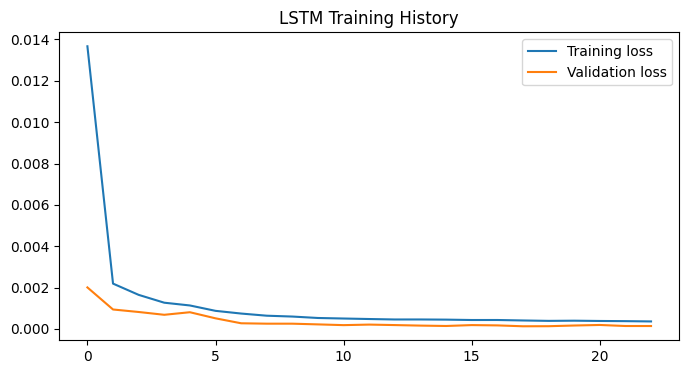

In [145]:
plt.figure(figsize=(8,4))
plt.plot(
    history.history["loss"],
    label="Training loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)
plt.legend()
plt.title(
    "LSTM Training History"
)
plt.show()

In [146]:
prediction = model.predict(
    X_test
)

548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step


In [147]:
prediction_original = scaler.inverse_transform(
    prediction
)
y_test_original = scaler.inverse_transform(
    y_test
)

In [148]:
lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        prediction_original
    )
)

In [149]:
lstm_mae = mean_absolute_error(
    y_test_original,
    prediction_original
)

In [150]:
print(
    "LSTM RMSE:",
    lstm_rmse
)
print(
    "LSTM MAE:",
    lstm_mae
)

LSTM RMSE: 137.2940915201861
LSTM MAE: 103.79047276048364


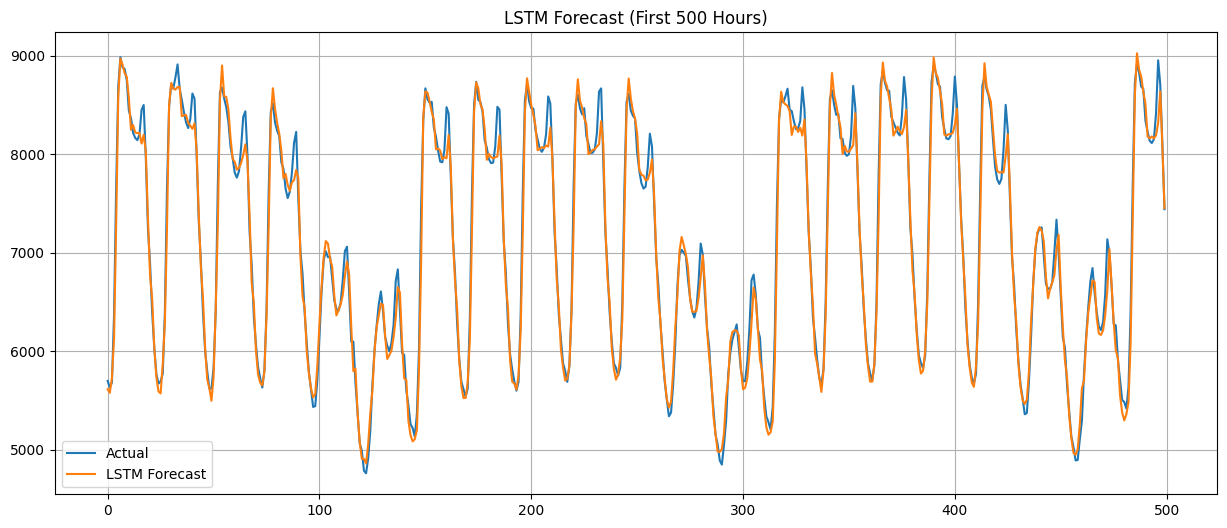

In [151]:
plt.figure(figsize=(15,6))
plt.plot(
    y_test_original[:500],
    label="Actual"
)
plt.plot(
    prediction_original[:500],
    label="LSTM Forecast"
)
plt.title(
    "LSTM Forecast (First 500 Hours)"
)
plt.legend()
plt.grid()
plt.show()

In [152]:
final_results = pd.DataFrame(
    {
        "Model": [
            "Mean",
            "Naive",
            "Seasonal Naive",
            "Drift",
            "SARIMA",
            "SARIMAX",
            "Gradient Boosting",
            "LSTM"
        ],
        "RMSE": [
            results_df.loc[0,"RMSE"],
            results_df.loc[1,"RMSE"],
            results_df.loc[2,"RMSE"],
            results_df.loc[3,"RMSE"],
            sarima_rmse,
            sarimax_rmse,
            gbr_rmse,
            lstm_rmse
        ],
        "MAE": [
            results_df.loc[0,"MAE"],
            results_df.loc[1,"MAE"],
            results_df.loc[2,"MAE"],
            results_df.loc[3,"MAE"],
            sarima_mae,
            sarimax_mae,
            gbr_mae,
            lstm_mae
        ]
    }
)

In [154]:
final_results.to_csv(
    "final_model_comparison.csv",
    index=False
)

# 10. Comparison of Forecasting Models

All models were evaluated using Root Mean Square Error (RMSE) and Mean Absolute Error (MAE).

Lower values indicate better forecasting performance.

The comparison allows evaluation of both statistical and machine learning approaches.

In [158]:
final_results.sort_values("RMSE", ascending=True)

,Model,RMSE,MAE
7,LSTM,137.294092,103.790473
6,Gradient Boosting,274.121888,206.163813
5,SARIMAX,286.453064,222.404057
4,SARIMA,295.137021,226.629320
2,Seasonal Naive,424.459965,325.753053
0,Mean,762.119830,646.913283
1,Naive,762.574416,652.159760
3,Drift,978.935316,833.887468


# 11. Conclusion

This study compared traditional statistical forecasting models with machine learning and deep learning approaches for German electricity demand forecasting.

The LSTM model achieved the lowest forecasting error, demonstrating the ability of neural networks to capture complex temporal patterns.

However, model selection should consider more than accuracy alone. Statistical models such as SARIMAX provide better interpretability and easier operational deployment, while machine learning approaches provide improved predictive capability.

Future improvements could include additional weather variables, holiday information, renewable generation data, and advanced deep learning architectures.